# Introduction

Objective of this notebook is to explore customer behavior, sales performance and operational metrics using the analytical datasets prepared in PostgreSQL.

## Import statements and setting style

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import src.helpers as hp
import src.plotting as plot

In [2]:
pd.options.display.float_format = "{:,.2f}".format

plot.set_plot_style()

## Dataset grain

- Customer summary: one row per unique customer
- Monthly sales summary: one row per purchase month
- Product summary: one row per product category
- Delivery summary: one row per order month
- Review summary: one row per review/order

# Data Load

In [3]:
df_customers = hp.load_view("vw_customer_summary_python")
df_monthly_sales = hp.load_view("vw_monthly_sales_summary")
df_products = hp.load_view("vw_products_summary")
df_delivery = hp.load_view("vw_delivery_summary")
df_reviews = hp.load_view("vw_order_review_summary")

# Monthly Sales Summary Overview

In [4]:
df_monthly_sales.tail()

,purchase_month,total_orders,total_customers,total_revenue,avg_order_value,avg_orders_per_customer,cancelled_orders,cancellation_rate,unavailable_orders,unavailable_rate
20,2018-06-01,6167,6128,"1,023,880.50",166.03,1,18,0.29,4,0.06
21,2018-07-01,6292,6230,"1,066,540.75",169.51,1,41,0.65,18,0.29
22,2018-08-01,6512,6460,"1,022,425.32",157.01,1,84,1.29,7,0.11
23,2018-09-01,16,14,"4,439.54",277.47,1,15,93.75,0,0.00
24,2018-10-01,4,4,589.67,147.42,1,4,100.00,0,0.00


The dataset ends in August 2018; all data in September and October represent transactions whose processing or cancellation was delayed in system time and should be excluded from trend analysis.

In [5]:
df_monthly_sales_clean = df_monthly_sales[df_monthly_sales["purchase_month"] < "2018-09-01"]

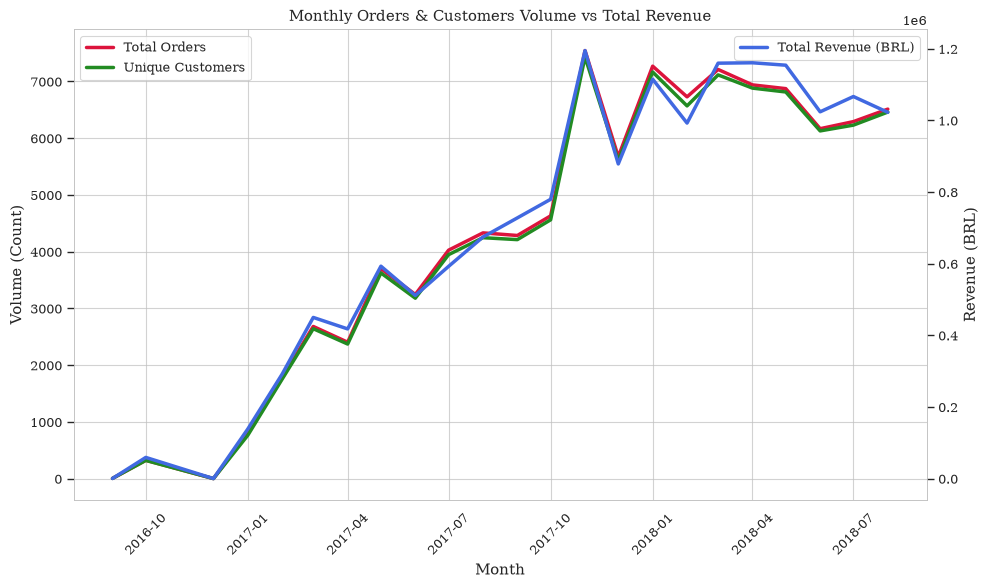

In [6]:
fig, ax1, ax2 = plot.create_figure()

sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax1, **plot.METRIC_CONFIG["total_orders"])
sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax1, **plot.METRIC_CONFIG["total_customers"])
sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax2, **plot.METRIC_CONFIG["total_revenue"])

plot.finish_plot(
    ax1=ax1,
    title="Monthly Orders & Customers Volume vs Total Revenue",
    xlabel="Month",
    ax1_ylabel="Volume (Count)",
    ax2=ax2,
    ax2_ylabel="Revenue (BRL)"
)

The close alignment between monthly orders and unique customers suggests that most customers place only one order. A dedicated cohort analysis would be required to measure retention directly.

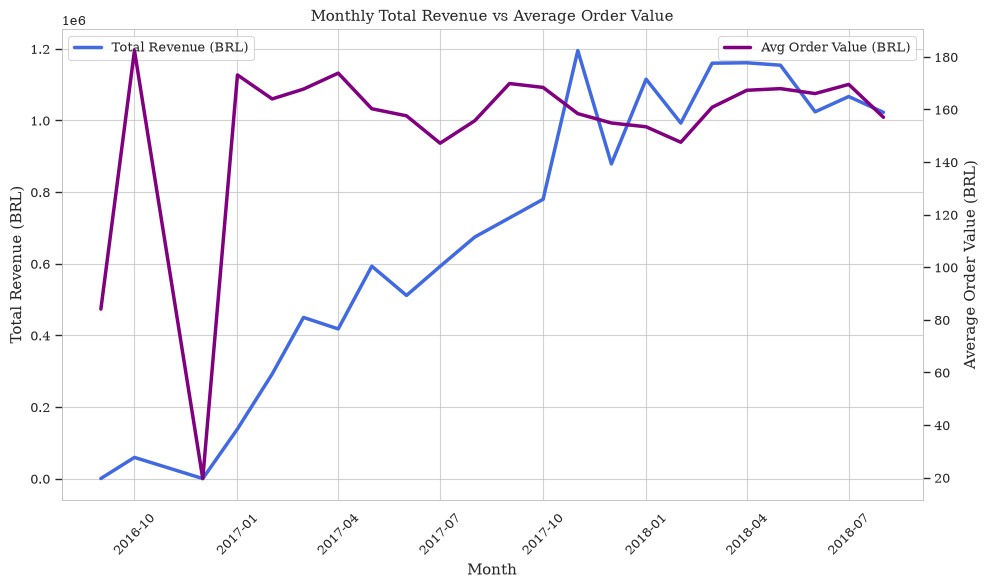

In [7]:
fig, ax1, ax2 = plot.create_figure()

sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax1, **plot.METRIC_CONFIG["total_revenue"])
sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax2, **plot.METRIC_CONFIG["avg_order_value"])

plot.finish_plot(
    ax1=ax1,
    title="Monthly Total Revenue vs Average Order Value",
    xlabel="Month",
    ax1_ylabel="Total Revenue (BRL)",
    ax2=ax2,
    ax2_ylabel="Average Order Value (BRL)"
)

The comparison of Total Revenue and Average Order Value further supports the view that the business scales through volume, as Average Order Value remains almost flat throughout the analysed period.

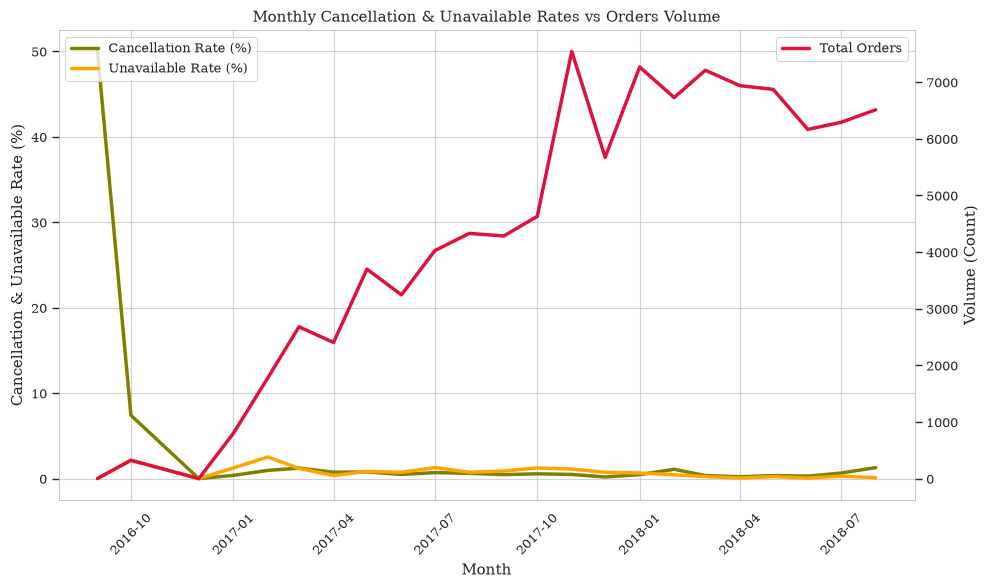

In [8]:
fig, ax1, ax2 = plot.create_figure()

sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax1, **plot.METRIC_CONFIG["cancellation_rate"])
sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax1, **plot.METRIC_CONFIG["unavailable_rate"])
sns.lineplot(data=df_monthly_sales_clean, x="purchase_month", ax=ax2, **plot.METRIC_CONFIG["total_orders"])

plot.finish_plot(
    ax1=ax1,
    title="Monthly Cancellation & Unavailable Rates vs Orders Volume",
    xlabel="Month",
    ax1_ylabel="Cancellation & Unavailable Rate (%)",
    ax2=ax2,
    ax2_ylabel="Volume (Count)"
)

While total orders scaled significantly, the cancellation and unavailability rates remained consistently low, indicating efficient order processing during periods of high volume.

# Customer Summary Overview

In [9]:
df_customers.sort_values("total_spent", ascending=False).head(10)

,customer_unique_id,customer_city,customer_state,first_purchase_date,first_purchase_month,last_purchase_date,customer_tenure_days,total_orders,failed_orders,total_spent,avg_order_value
3826,0a0a92112bd4c708ca5fde585afaa872,rio de janeiro,RJ,2017-09-29 15:24:52,2017-09-01,2017-09-29 15:24:52,0,1,0,"13,664.08","13,664.08"
81962,da122df9eeddfedc1dc1f5349a1a690c,araruama,RJ,2017-04-01 15:58:40,2017-04-01,2017-04-01 15:58:41,0,2,0,"7,571.63","3,785.82"
44447,763c8b1c9c68a0229c42c9fc6f662b93,vila velha,ES,2018-07-15 14:49:44,2018-07-01,2018-07-15 14:49:44,0,1,0,"7,274.88","7,274.88"
82808,dc4802a71eae9be1dd28f5d788ceb526,campo grande,MS,2017-02-12 20:37:36,2017-02-01,2017-02-12 20:37:36,0,1,0,"6,929.31","6,929.31"
26205,459bef486812aa25204be022145caa62,vitoria,ES,2018-07-25 18:10:17,2018-07-01,2018-07-25 18:10:17,0,1,0,"6,922.21","6,922.21"
95806,ff4159b92c40ebe40454e3e6a7c35ed6,marilia,SP,2017-05-24 18:14:34,2017-05-01,2017-05-24 18:14:34,0,1,0,"6,726.66","6,726.66"
24121,4007669dec559734d6f53e029e360987,divinopolis,MG,2017-11-24 11:03:35,2017-11-01,2017-11-24 11:03:35,0,1,0,"6,081.54","6,081.54"
89688,eebb5dda148d3893cdaf5b5ca3040ccb,maua,SP,2017-04-18 18:50:13,2017-04-01,2017-04-18 18:50:13,0,1,0,"4,764.34","4,764.34"
27441,48e1ac109decbb87765a3eade6854098,joao pessoa,PB,2018-06-22 12:23:19,2018-06-01,2018-06-22 12:23:19,0,1,0,"4,681.78","4,681.78"
75269,c8460e4251689ba205045f3ea17884a1,porto alegre,RS,2018-08-07 09:03:02,2018-08-01,2018-08-08 14:27:15,1,4,0,"4,655.91","1,163.98"


The top 10 customer ranking reflects a severe retention deficit, with only two repeated buyers appearing on the list and just a single retained customer making it into the top 3. This supports the hypothesis that Olist scales through customers volume since even the highest-value accounts are dominated by one-time transactions rather than sustained loyalty.

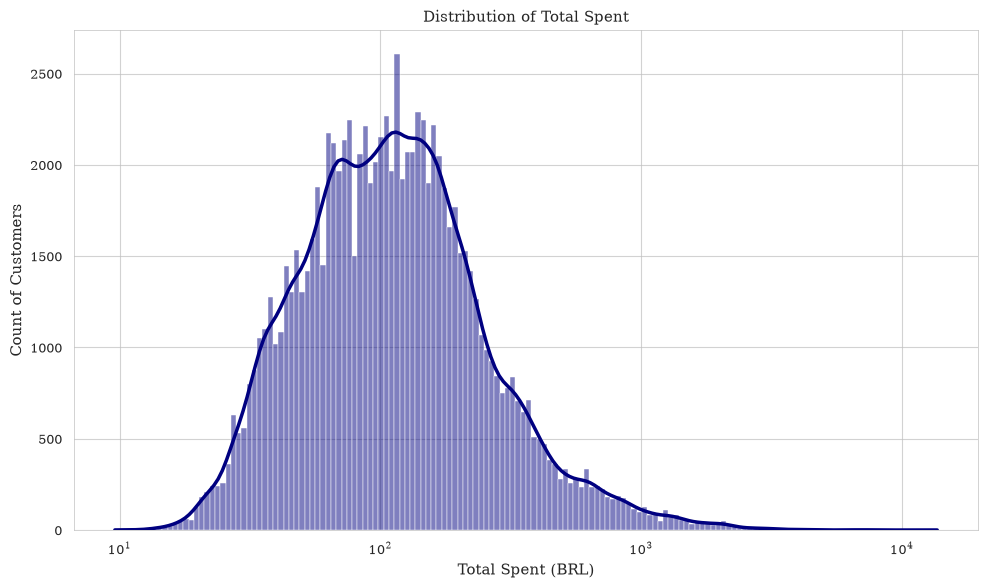

In [10]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.histplot(data=df_customers, x="total_spent", kde=True, color=plot.METRIC_CONFIG["total_spent"]["color"], ax=ax1, log_scale=True)

plot.finish_plot(
    ax1=ax1,
    title="Distribution of Total Spent",
    xlabel="Total Spent (BRL)",
    ax1_ylabel="Count of Customers",
    legend=False
)

The log-scaled distribution shows that most customers spend within a central range, which indicates a highly consistent purchasing behavior across the entire customer base, with very few extreme outliers on either end.

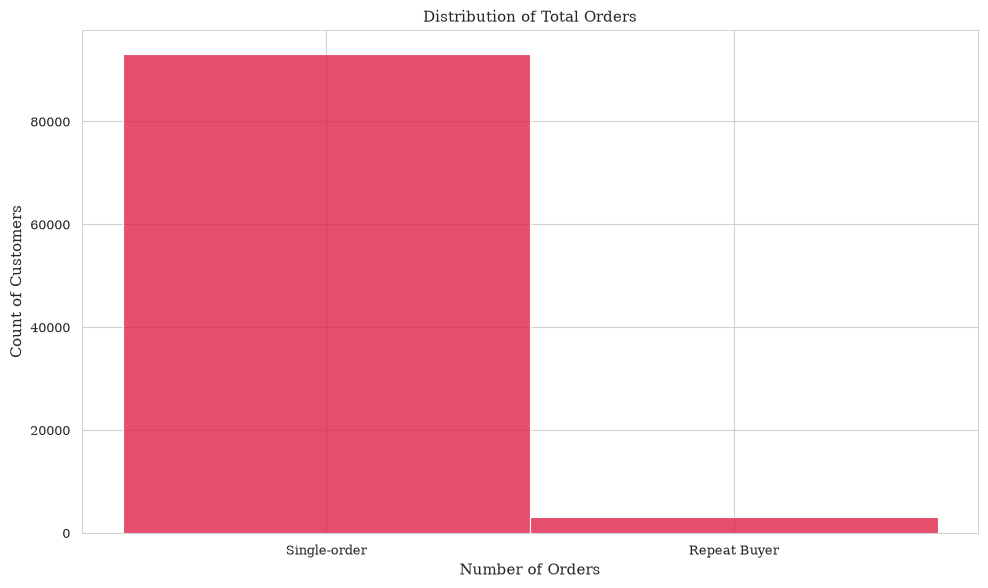

In [11]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

df_customers["customer_type"] = df_customers["total_orders"].apply(
    lambda x: "Single-order" if x == 1 else "Repeat Buyer"
)

sns.histplot(data=df_customers, x="customer_type", kde=False, color=plot.METRIC_CONFIG["total_orders"]["color"], ax=ax1, discrete=True)

plot.finish_plot(
    ax1=ax1,
    title="Distribution of Total Orders",
    xlabel="Number of Orders",
    ax1_ylabel="Count of Customers",
    legend=False
)

The distribution of Total Orders supports prior findings; the vast majority of customers are one-time buyers.

In [12]:
correlation_cols = ["total_orders", "failed_orders", "total_spent", "avg_order_value"]
df_corr_data = df_customers[correlation_cols]

In [13]:
corr_matrix = df_corr_data.corr(method="spearman")
corr_matrix

,total_orders,failed_orders,total_spent,avg_order_value
total_orders,1.00,0.05,0.16,0.01
failed_orders,0.05,1.00,0.01,0.01
total_spent,0.16,0.01,1.00,0.99
avg_order_value,0.01,0.01,0.99,1.00


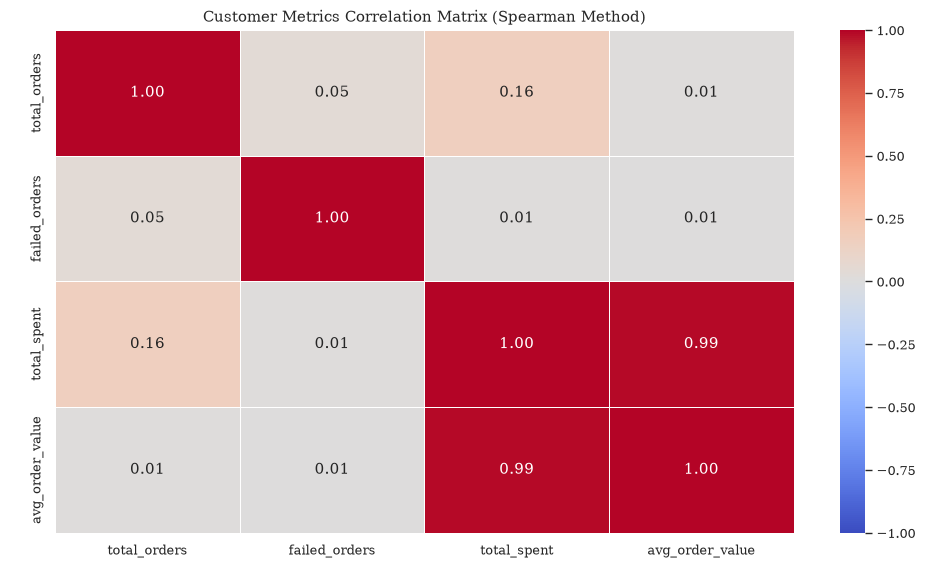

In [14]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.heatmap(
    corr_matrix,
    ax=ax1,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plot.finish_plot(
    ax1=ax1,
    title="Customer Metrics Correlation Matrix (Spearman Method)",
    xlabel=" ",
    ax1_ylabel=" ",
    legend=False
)

The correlation between avg_order_value and total_spent (0.99) and between total_orders and total_spent (0.16) indicates that the total revenue generated by a customer is often driven by the high value of their order and not by how many times they return to buy. The correlation between total_orders and avg_order_value (0.01) gives us additional insight - even customers who happen to buy more than once do not change their habits. There is also no significant correlation between failed_orders and any other metric, suggesting that failed orders occur independently of order sizes and value.
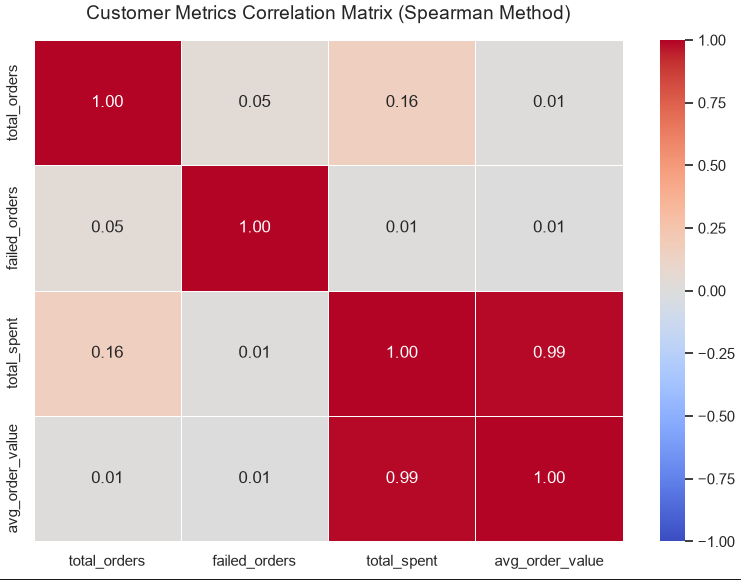

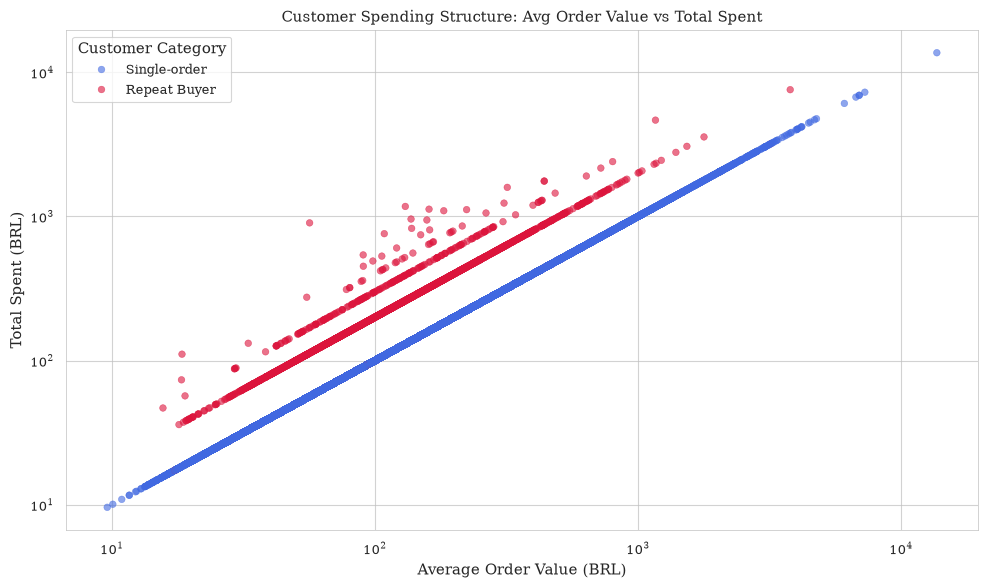

In [15]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.scatterplot(
    data=df_customers,
    ax=ax1,
    x="avg_order_value",
    y="total_spent",
    hue="customer_type",
    palette={"Single-order": "royalblue", "Repeat Buyer": "crimson"},
    alpha=0.6,
    edgecolor=None,
)

ax1.legend(title="Customer Category")
ax1.set_xscale("log")
ax1.set_yscale("log")

plot.finish_plot(
    ax1=ax1,
    title="Customer Spending Structure: Avg Order Value vs Total Spent",
    xlabel="Average Order Value (BRL)",
    ax1_ylabel="Total Spent (BRL)",
    legend=False
)

Customer Spending Structure is consistent with conclusion that the strong correlation is driven by single-order customers. Repeat buyers visibly shift above this baseline, showing exactly how much their total spending increased with each additional order.

# Products Summary Overview

In [16]:
df_products.sort_values('total_revenue', ascending=False).head(10)

,product_category_name,total_orders,products_sold,total_revenue,avg_product_price,total_freight,avg_freight
44,health_beauty,8800,9634,"1,255,695.13",130.34,"181,970.65",18.89
73,watches_gifts,5604,5970,"1,198,185.21",200.70,"100,107.26",16.77
7,bed_bath_table,9399,11097,"1,035,964.06",93.36,"204,422.07",18.42
67,sports_leisure,7673,8590,"979,740.92",114.06,"167,503.71",19.50
15,computers_accessories,6654,7781,"904,322.02",116.22,"146,619.56",18.84
39,furniture_decor,6425,8298,"727,465.05",87.67,"172,160.99",20.75
50,housewares,5847,6915,"626,825.80",90.65,"145,209.34",21.00
20,cool_stuff,3616,3779,"620,770.49",164.27,"83,315.75",22.05
5,auto,3872,4204,"586,585.73",139.53,"92,020.91",21.89
43,garden_tools,3505,4328,"481,009.94",111.14,"98,515.26",22.76


In [17]:
df_pareto = df_products.sort_values(by="total_revenue", ascending=False).copy()
df_pareto["cum_percentage"] = (
    df_pareto["total_revenue"].cumsum() / df_pareto["total_revenue"].sum() * 100
)
df_pareto_skew = df_pareto.head(20)

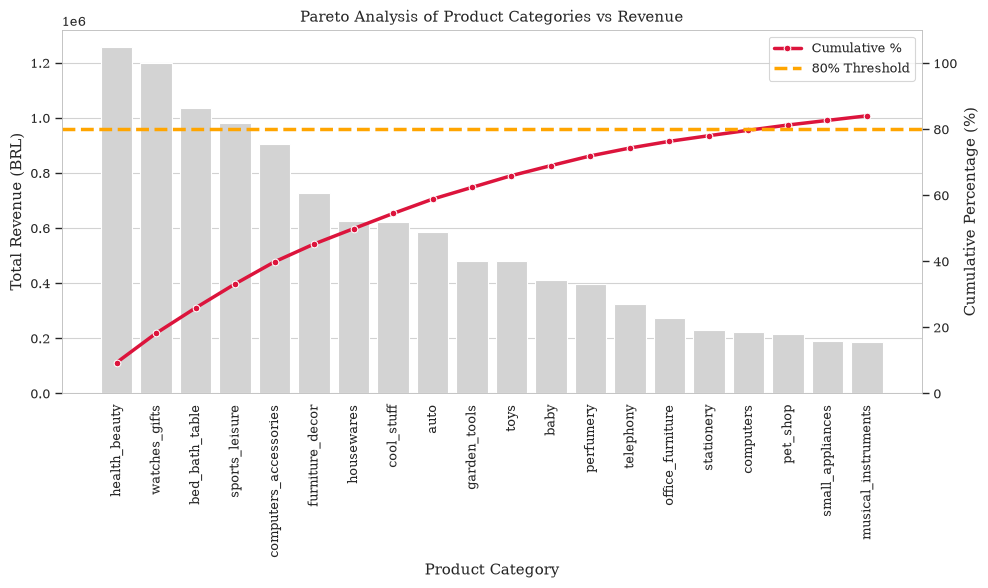

In [18]:
fig, ax1, ax2 = plot.create_figure(rotate_x=False)

sns.barplot(data=df_pareto_skew, x="product_category_name", y="total_revenue", ax=ax1, color="lightgray")
sns.lineplot(data=df_pareto_skew, x="product_category_name", y="cum_percentage", ax=ax2, color="crimson", marker="o", sort=False, label="Cumulative %")
ax2.axhline(80, color="orange", linestyle="--", label="80% Threshold")

ax2.set_ylim(0, 110)
ax1.tick_params(axis="x", rotation=90)

plot.finish_plot(
    ax1=ax1,
    title="Pareto Analysis of Product Categories vs Revenue",
    xlabel="Product Category",
    ax1_ylabel="Total Revenue (BRL)",
    legend=False,
    ax2=ax2,
    ax2_ylabel="Cumulative Percentage (%)"
)

While the top three revenue-generating categories—health & beauty, watches & gifts, and bed & bath—were the only ones to cross the $1M milestone, they can hardly be considered as dominating the overall revenue share. The Pareto analysis further supports that - the marketplace does not follow a strict 80/20 rule; instead, it takes about 16 core categories to cross the 80% cumulative revenue threshold. This indicates a healthier, more balanced revenue distribution than expected, reducing the business risk of being overly dependent on just two or three products.

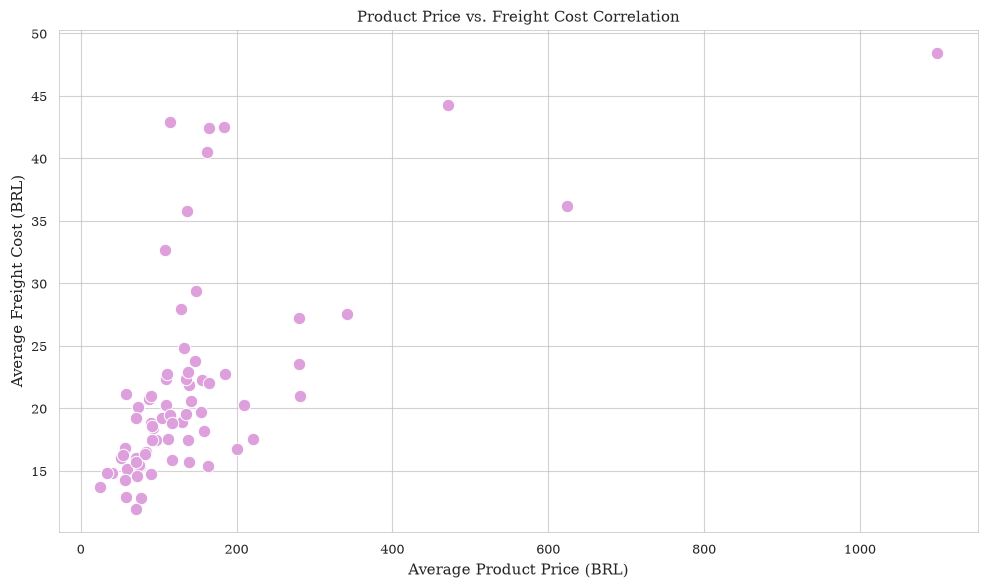

In [19]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.scatterplot(data=df_products, x="avg_product_price", s=80, ax=ax1, **plot.METRIC_CONFIG["avg_freight"])

plot.finish_plot(
    ax1=ax1,
    title="Product Price vs. Freight Cost Correlation",
    xlabel="Average Product Price (BRL)",
    ax1_ylabel="Average Freight Cost (BRL)",
    legend=False
)

In [20]:
product_correlation_cols = ["avg_product_price", "avg_freight"]
product_corr_data = df_products[product_correlation_cols]
product_corr_data.corr()

,avg_product_price,avg_freight
avg_product_price,1.00,0.63
avg_freight,0.63,1.00


Product Price vs. Freight Cost Correlation provides us with insight that while higher price can indicate higher freight costs the product price is not the only component of that equation.

# Delivery Summary Overview

In [21]:
df_delivery.head()

,order_month,completed_orders,avg_delivery_days,median_delivery_days,avg_processing_days,avg_shipping_days,on_time_orders,late_orders,on_time_rate,avg_estimation_error
0,2016-09-01,1,55.00,55.00,0.00,2.00,0,1,0.00,36.00
1,2016-10-01,265,20.00,18.00,1.00,6.00,263,2,99.25,-37.00
2,2016-12-01,1,5.00,5.00,0.00,1.00,1,0,100.00,-22.00
3,2017-01-01,750,13.00,11.00,1.00,9.00,728,22,97.07,-27.00
4,2017-02-01,1653,13.00,11.00,0.00,10.00,1604,49,97.04,-19.00


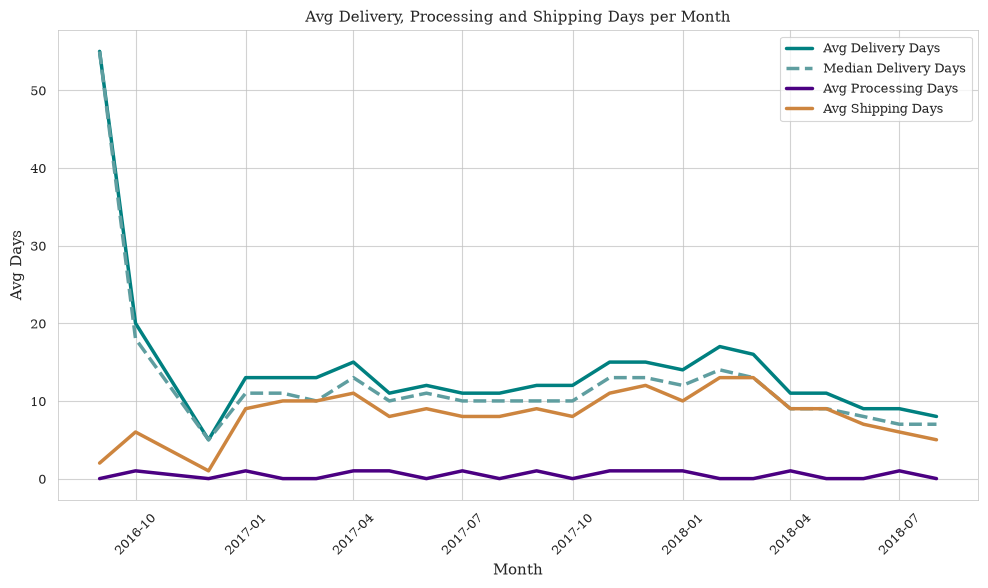

In [22]:
fig, ax1 = plot.create_figure(sec_y=False)

sns.lineplot(data=df_delivery, x="order_month", ax=ax1, **plot.METRIC_CONFIG["avg_delivery_days"])
sns.lineplot(data=df_delivery, x="order_month", ax=ax1, **plot.METRIC_CONFIG["median_delivery_days"])
sns.lineplot(data=df_delivery, x="order_month", ax=ax1, **plot.METRIC_CONFIG["avg_processing_days"])
sns.lineplot(data=df_delivery, x="order_month", ax=ax1, **plot.METRIC_CONFIG["avg_shipping_days"])

plot.finish_plot(
    ax1=ax1,
    title="Avg Delivery, Processing and Shipping Days per Month",
    xlabel="Month",
    ax1_ylabel="Avg Days",
    legend=False
)

The internal order processing and shipping days remain low and stable throughout the entire period. After the spike during platform launch in late 2016 average delivery days stabilized.

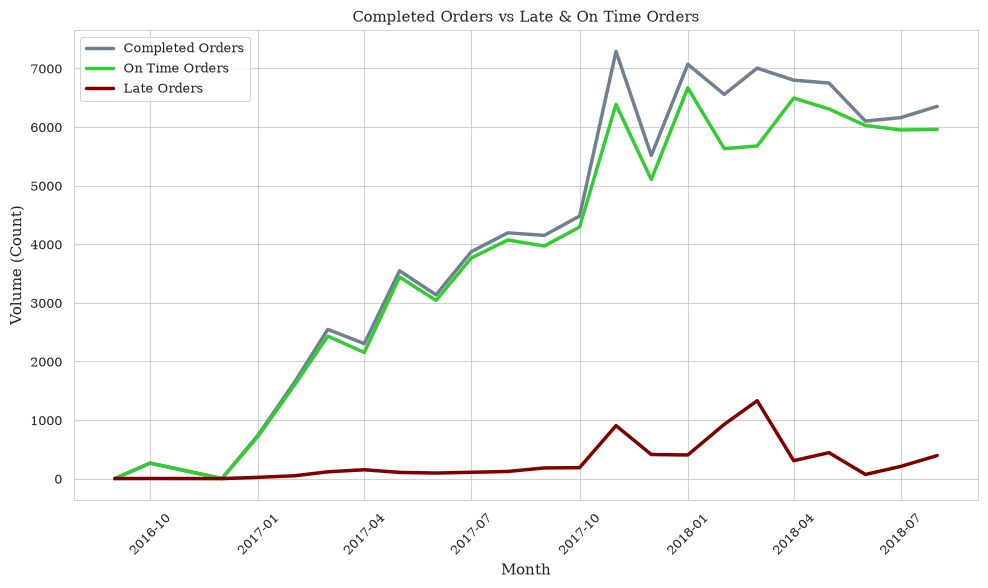

In [23]:
fig, ax1 = plot.create_figure(sec_y=False)

sns.lineplot(data=df_delivery, x="order_month", ax=ax1, **plot.METRIC_CONFIG["completed_orders"])
sns.lineplot(data=df_delivery, x="order_month", ax=ax1, **plot.METRIC_CONFIG["on_time_orders"])
sns.lineplot(data=df_delivery, x="order_month", ax=ax1, **plot.METRIC_CONFIG["late_orders"])

plot.finish_plot(
    ax1=ax1,
    title="Completed Orders vs Late & On Time Orders",
    xlabel="Month",
    ax1_ylabel="Volume (Count)",
    legend=False
)

The vast majority of completed orders are delivered on time, with the green line closely following the total volume trend. Late orders remained negligible during initial growth but experienced noticeable, temporary spikes during peak volume periods in late 2017 and early 2018 before stabilizing again.

# Order Reviews Overview

In [24]:
df_reviews.head()

,review_id,order_id,customer_unique_id,review_score,review_sentiment,order_status,successful_order,purchase_month,delivery_days,delivery_delay_days,is_late_delivery
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,68a5590b9926689be4e10f4ae2db21a8,4,Positive,delivered,True,2018-01-01,6.00,-16.00,False
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,64190b91b656ab8f37eb89b93dc84584,5,Positive,delivered,True,2018-02-01,9.00,-5.00,False
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,1d47144362c14e94ccdd213e8ec277d5,5,Positive,delivered,True,2018-02-01,13.00,-21.00,False
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,c8cf6cb6b838dc7a33ed199b825e8616,5,Positive,delivered,True,2017-04-01,11.00,-20.00,False
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,d16000272660a1fef81482ad75ba572a,5,Positive,delivered,True,2018-02-01,18.00,-9.00,False


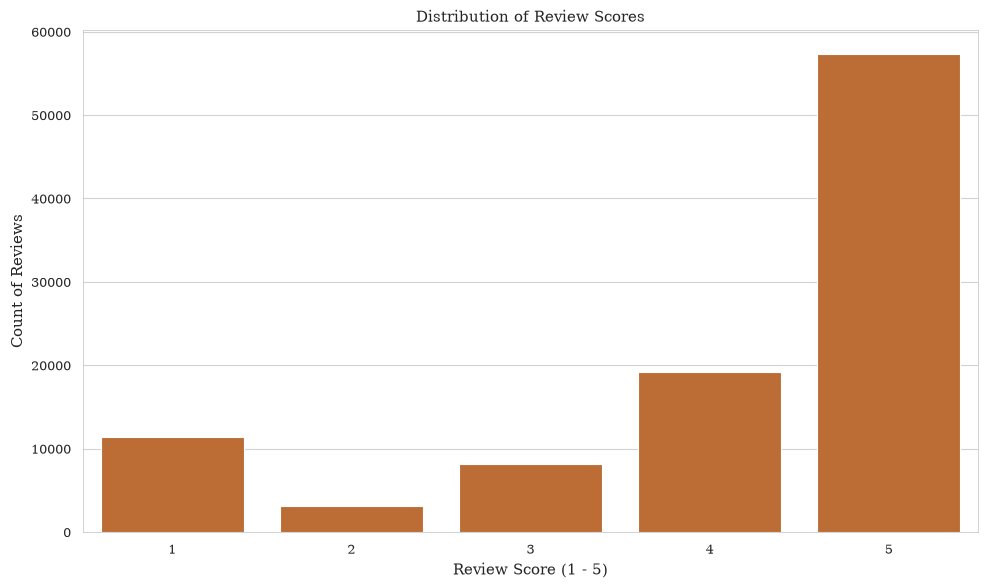

In [25]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.countplot(data=df_reviews, x="review_score", ax=ax1, **plot.METRIC_CONFIG["review_score"])

plot.finish_plot(
    ax1=ax1,
    title="Distribution of Review Scores",
    xlabel="Review Score (1 - 5)",
    ax1_ylabel="Count of Reviews",
    legend=False
)

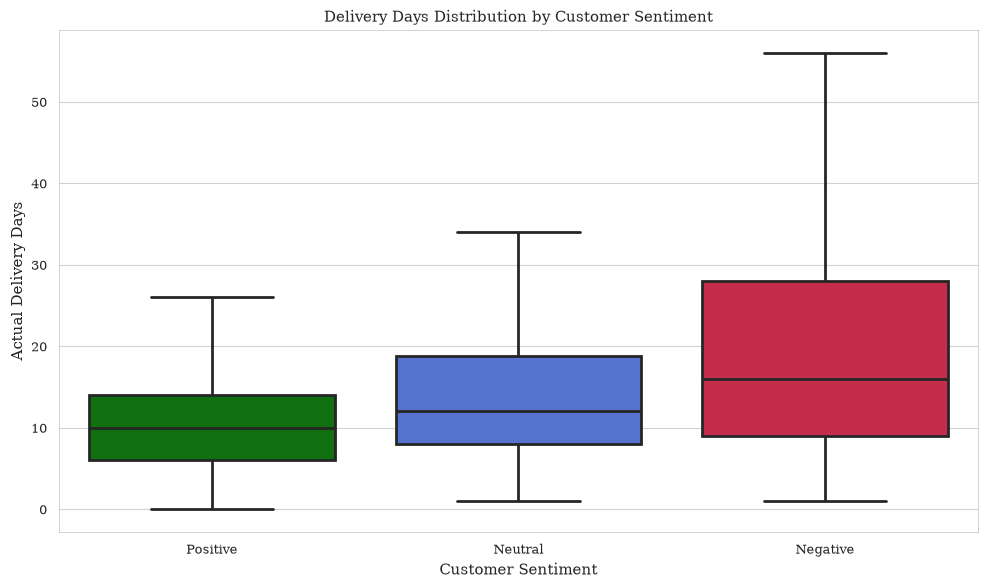

In [26]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.boxplot(
    data=df_reviews,
    ax=ax1,
    x="review_sentiment",
    y="delivery_days",
    order=["Positive", "Neutral", "Negative"],
    hue="review_sentiment",
    palette={"Positive":"green", "Neutral":"royalblue","Negative": "crimson"},
    legend= False,
    showfliers=False,
    linewidth=2
)

plot.finish_plot(
    ax1=ax1,
    title="Delivery Days Distribution by Customer Sentiment",
    xlabel="Customer Sentiment",
    ax1_ylabel="Actual Delivery Days",
    legend=False
)

Longer delivery times are associated with lower customer review scores, as the median delivery time for negative reviews is noticeably higher at around 16 days compared to just 10 days for positive ones. Furthermore, the wide spread in the negative category shows that extreme delivery delays—sometimes stretching over 50 days—almost guarantee poor customer sentiment.

# Cross-View Analysis

## Geographical Satisfaction and Logistics

In [27]:
df_reviews_by_customer = df_reviews.groupby("customer_unique_id", as_index=False).agg(
    avg_review_score=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    review_count=("review_score", "count")
    )

In [28]:
df_customers_reviews = pd.merge(df_customers, df_reviews_by_customer, on="customer_unique_id", how="left", validate="one_to_one")

In [29]:
df_geo = df_customers_reviews.groupby("customer_state").agg({
    "total_orders": "sum",
    "avg_review_score": "mean",
    "avg_delivery_days": "mean"
})

In [30]:
df_geo.sort_values("total_orders", ascending=False).head(5)

,total_orders,avg_review_score,avg_delivery_days
customer_state,,,
SP,41752,4.17,8.69
RJ,12854,3.88,15.17
MG,11631,4.13,11.93
RS,5466,4.13,15.22
PR,5043,4.18,11.91


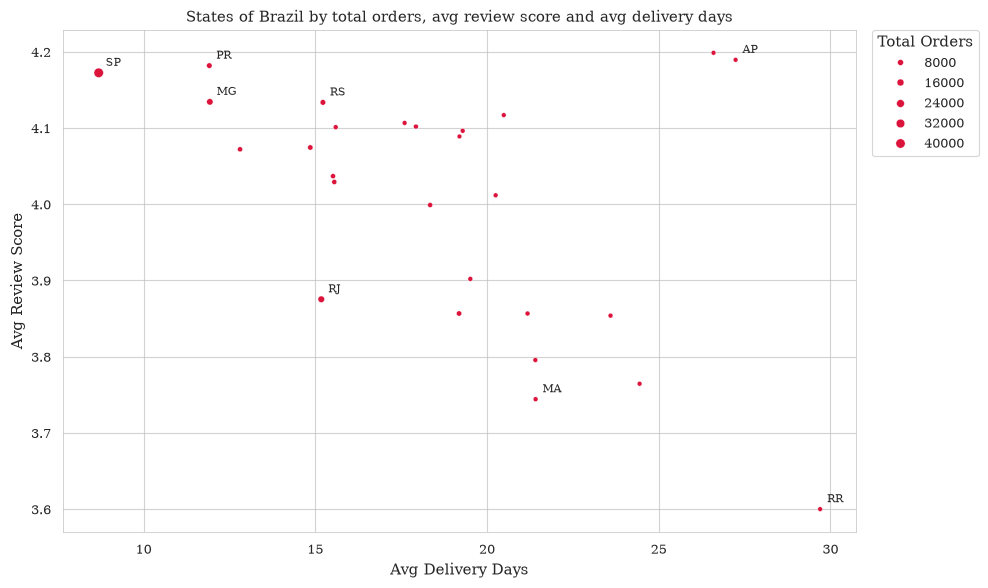

In [31]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.scatterplot(
    data=df_geo,
    ax=ax1,
    x="avg_delivery_days",
    y="avg_review_score",
    size="total_orders",
    color=plot.METRIC_CONFIG["total_orders"]["color"]
)

important_states = set(
    df_geo.nlargest(5, "total_orders").index
    .union(df_geo.nlargest(2, "avg_delivery_days").index)
    .union(df_geo.nsmallest(2, "avg_review_score").index)
)

for state in important_states:
    row = df_geo.loc[state]

    ax1.annotate(
        state,
        xy=(row["avg_delivery_days"], row["avg_review_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

plt.legend(title="Total Orders", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plot.finish_plot(
    ax1=ax1,
    title="States of Brazil by total orders, avg review score and avg delivery days",
    xlabel="Avg Delivery Days",
    ax1_ylabel="Avg Review Score",
    legend=False
)

In [32]:
corr_matrix_geo = df_geo.corr(method="spearman")
corr_matrix_geo

,total_orders,avg_review_score,avg_delivery_days
total_orders,1.00,0.09,-0.81
avg_review_score,0.09,1.00,-0.41
avg_delivery_days,-0.81,-0.41,1.00


There is a clear negative correlation between logistical performance and customer satisfaction, as states with longer delivery times show a significant drop not only in review scores (-0.41) but also in the volume of orders (-0.81). São Paulo (SP) dominates the market as a major outlier, delivering the highest volume of orders with the fastest transit times and top-tier ratings.

## Customers Sentiment

In [33]:
df_sentiment = df_customers_reviews[["customer_unique_id", "total_spent", "total_orders", "failed_orders", "avg_review_score"]].copy()
df_sentiment.dropna(subset="avg_review_score", inplace=True)

In [34]:
df_sentiment["review_group"] = df_sentiment["avg_review_score"].round().astype(int)
df_sentiment

,customer_unique_id,total_spent,total_orders,failed_orders,avg_review_score,review_group
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,0,5.00,5
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,0,4.00,4
2,0000f46a3911fa3c0805444483337064,86.22,1,0,3.00,3
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,0,4.00,4
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,0,5.00,5
...,...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,"2,067.42",1,0,5.00,5
96092,fffea47cd6d3cc0a88bd621562a9d061,84.58,1,0,4.00,4
96093,ffff371b4d645b6ecea244b27531430a,112.46,1,0,5.00,5
96094,ffff5962728ec6157033ef9805bacc48,133.69,1,0,5.00,5


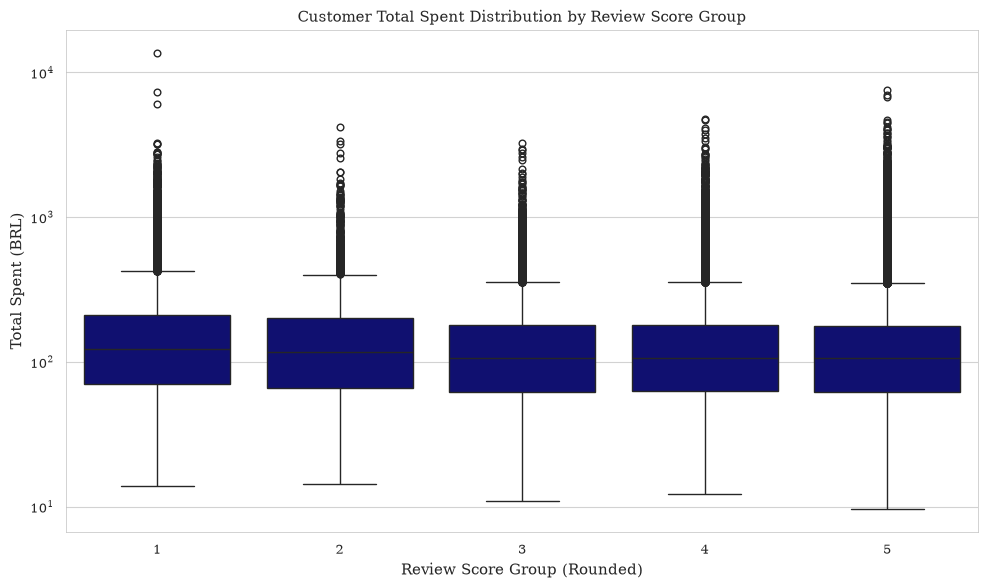

In [35]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.boxplot(data=df_sentiment, x="review_group", y="total_spent" ,ax=ax1, **plot.METRIC_CONFIG["total_spent"])

ax1.set_yscale("log")

plot.finish_plot(
    ax1=ax1,
    title="Customer Total Spent Distribution by Review Score Group",
    xlabel="Review Score Group (Rounded)",
    ax1_ylabel="Total Spent (BRL)",
    legend=False
)

The Customer Total Spent Distribution by Review Score Group shows no correlation between a customer's total spent and their review scores, as the spending distribution remains identical across all rating groups. This indicates that customer satisfaction on Olist is more strongly associated with operational factors than with transaction value.

In [36]:
df_sentiment_copy = df_sentiment.copy()
df_sentiment_copy["had_failed_orders"] = df_sentiment_copy["failed_orders"].apply(lambda x: "Yes" if x > 0 else "No")

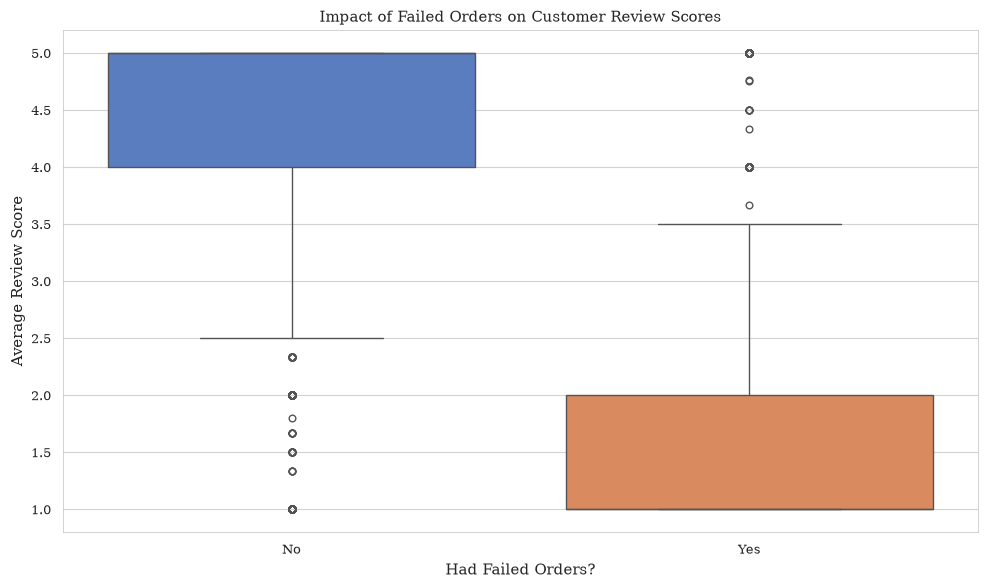

In [37]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.boxplot(
    data=df_sentiment_copy,
    ax=ax1,
    x="had_failed_orders",
    y="avg_review_score",
    hue="had_failed_orders",
    palette="muted"
)

plot.finish_plot(
    ax1=ax1,
    title="Impact of Failed Orders on Customer Review Scores",
    xlabel="Had Failed Orders?",
    ax1_ylabel="Average Review Score",
    legend=False
)

Customers with at least one failed order report substantially lower average review scores. This highlights that operational failures are associated with substantially lower customer review scores.

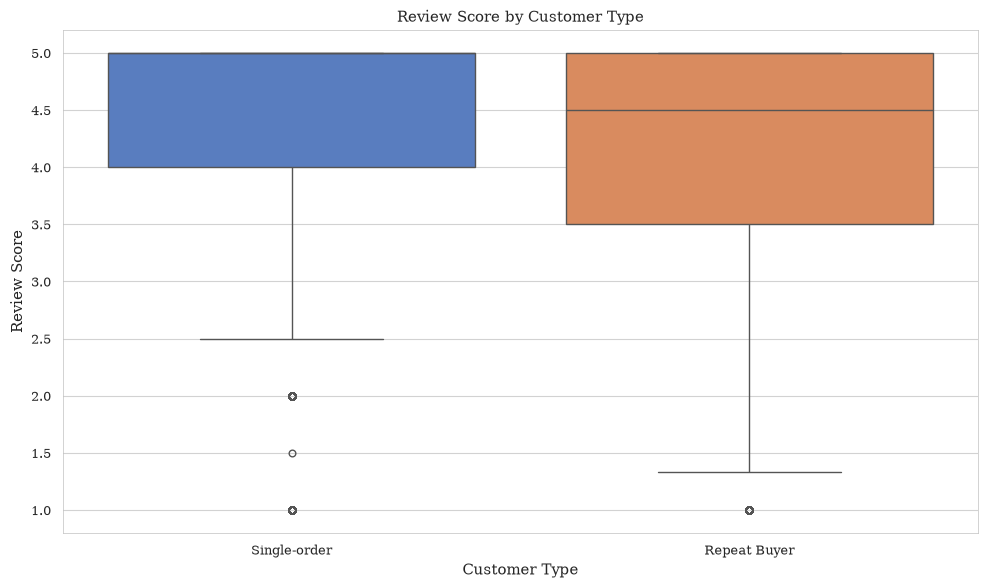

In [38]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

df_sentiment["customer_type"] = df_sentiment["total_orders"].apply(
    lambda x: "Single-order" if x == 1 else "Repeat Buyer"
)

sns.boxplot(
    data=df_sentiment,
    ax=ax1,
    x="customer_type",
    y="avg_review_score",
    hue="customer_type",
    palette="muted"
)

plot.finish_plot(
    ax1=ax1,
    title="Review Score by Customer Type",
    xlabel="Customer Type",
    ax1_ylabel="Review Score",
    legend=False
)

Average review scores do not show a clear relationship with the number of orders per customer.

## Sales vs Delivery

In [39]:
df_logistics = pd.merge(df_monthly_sales, df_delivery, left_on="purchase_month", right_on="order_month")

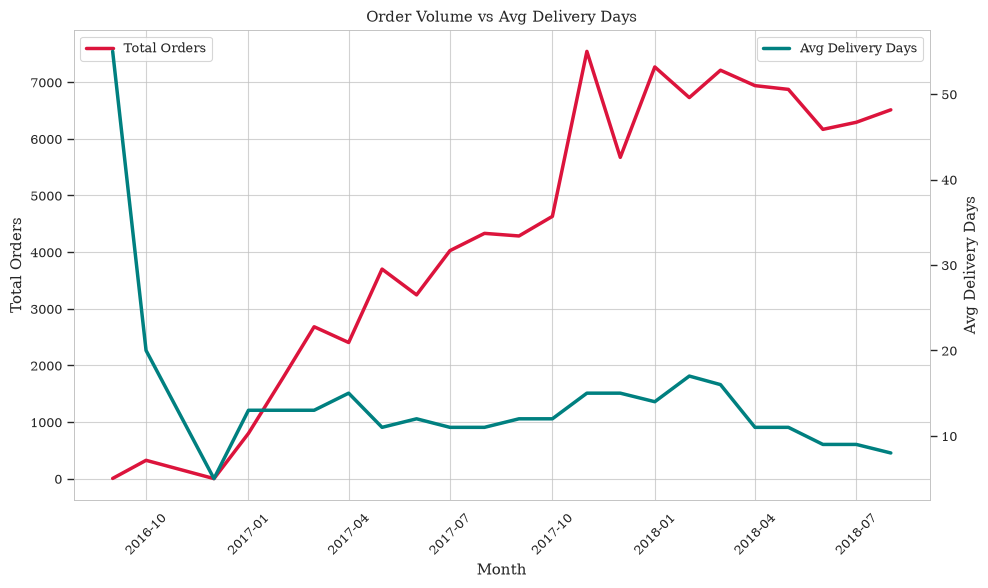

In [40]:
fig, ax1, ax2 = plot.create_figure()

sns.lineplot(data=df_logistics, x='purchase_month', ax=ax1, **plot.METRIC_CONFIG["total_orders"])
sns.lineplot(data=df_logistics, x='purchase_month', ax=ax2, **plot.METRIC_CONFIG["avg_delivery_days"])

plot.finish_plot(
    ax1=ax1,
    title="Order Volume vs Avg Delivery Days",
    xlabel="Month",
    ax1_ylabel="Total Orders",
    legend=True,
    ax2=ax2,
    ax2_ylabel="Avg Delivery Days"
)

Operational performance shows stable trend, as the average delivery time remains consistent despite a massive growth in monthly order volume. This indicates that logistics network scales effectively during high-demand peaks without causing delivery bottlenecks.

# Summary

1. The data supports the hypothesis that Olist suffers from very low customer retention. Additionally, it seems that even loyal customers do not display higher spending habits. Revenue growth is driven primarily by sales volume and new customer acquisition.
2. Based on analysis the platform offers a highly diverse range of product categories with no clear outliers.
3. Among the factors examined delivery speed and fulfillment success show the strongest associations with customer satisfaction. The majority of reviews remain positive, the vast majority of orders are delivered on time. Average delivery times are shortest in São Paulo (Olist's central hub) and longest in Roraima.

## Limitations

- The analysis is observational and does not establish causality.
- Retention is approximated using repeat purchase behavior and is not a cohort-based retention metric.
- Early months contain very small order volumes and may produce unstable rates.
- Geographic results may be affected by highly unequal sample sizes between states.